# 3. Data Modelling

Section 1: Additional Clean Up.

To ensure our regression results aren't "spurious," we transform raw prices into Log-Returns, which achieves stationarity. We also generate the Interaction Terms necessary to test the "Broken-Haven" hypothesis, specifically looking at how gold's relationship with the VIX changed after 2022.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# loading the raw ingested data
# using index_col=0 as the date is the first unnamed column in raw_data.csv
df = pd.read_csv('../data/raw_data.csv', index_col=0, parse_dates=True)
df.index.name = 'DATE'

# sorting the index to ensure Time-Series logic works correctly
df.sort_index(inplace=True)

# standardizing column names by removing special characters
df.columns = [
    col.replace("('", "").replace("', '", "_").replace("')", "")
    .replace("^", "").replace("-", "_").replace(".", "_").replace("=", "_")
    for col in df.columns
]

# dropping columns that are completely empty to prevent data loss
df.dropna(axis=1, how='all', inplace=True)

# forward filling missing daily gaps in monthly/quarterly macro data
df.ffill(inplace=True)

# calculating Log-Returns for stationarity
# formula: ln(Price_t) - ln(Price_t-1)
df['gold_ret'] = np.log(df['Close_MGC_F']).diff()
df['sp500_ret'] = np.log(df['Close_GSPC']).diff()
df['sp500_ret_lag'] = df['sp500_ret'].shift(1)

# defining structural break dummies for the analysis
# this marks the post-pandemic period starting in 2022
df['is_PostCovid'] = (df.index >= '2022-01-01').astype(int)

# creating interaction terms (VIX x Post-Covid) to test the structural shift
df['VIX_x_PostCovid'] = df['Close_VIX'] * df['is_PostCovid']

# removing NaNs created by the diff and lag functions
df.dropna(inplace=True)

# exporting the final cleaned dataset
df.to_csv('final_model_data.csv')

Section 2: Variable Selection via LASSO Regression

We use a LASSO (Least Absolute Shrinkage and Selection Operator) model to determine which macroeconomic drivers actually provide predictive power for gold returns. Because daily financial data is notoriously "noisy," the LASSO penalty helps us filter out insignificant variables. We use Time-Series Cross-Validation to ensure we aren't "peeking" into the future during the selection process.

In [9]:
# defining the features list explicitly to avoid NameErrors
features = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
            'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB', 'VIX_x_PostCovid']

# checking the correlation between features and the target (Gold Returns)
correlations = df[features + ['gold_ret']].corr()['gold_ret'].sort_values()
print("Correlations with Target:\n", correlations)

# converting Log-Returns to percentages (multiplying by 100)
# this increases model sensitivity to help prevent zeroed-out coefficients
y = df['gold_ret'] * 100
X = df[features]

# standardizing features to ensure Mean=0 and Std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# running LassoCV with an aggressive search path (eps=1e-8)
# a lowered epsilon forces the model to search for even the weakest signals
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=50000, alphas=1000, eps=1e-8)
lasso.fit(X_scaled, y)

print(f"Optimal Penalty (Alpha): {lasso.alpha_:.6f}")

# identifying variables that survived the shrinkage
coef_series = pd.Series(lasso.coef_, index=X.columns).sort_values(ascending=False)
selected_features = coef_series[coef_series != 0]

Correlations with Target:
 Close_DX_Y_NYB        -0.020322
expected_inflation    -0.003431
VIX_x_PostCovid       -0.002874
interest_rate         -0.002777
Close_VIX             -0.001413
sp500_ret              0.011956
sp500_ret_lag          0.015168
wti_crude_oil_price    0.017466
gold_ret               1.000000
Name: gold_ret, dtype: float64
Optimal Penalty (Alpha): 0.078128


Section 3: Analysis of Results

If the LASSO model returns zero for all coefficients, it suggests that the daily "noise" of the market outweighs the "signal" of our macro variables; consistent with the Random Walk Theory.

Regardless of the LASSO's prediction preference, we will include the Interaction Term in the final OLS model to formally test our research hypothesis, based on raw correlation strengths.

Fallback: Recommended Variables for Member 4 based on Correlation:
['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag']

Final Handoff for OLS: ['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag', 'VIX_x_PostCovid']


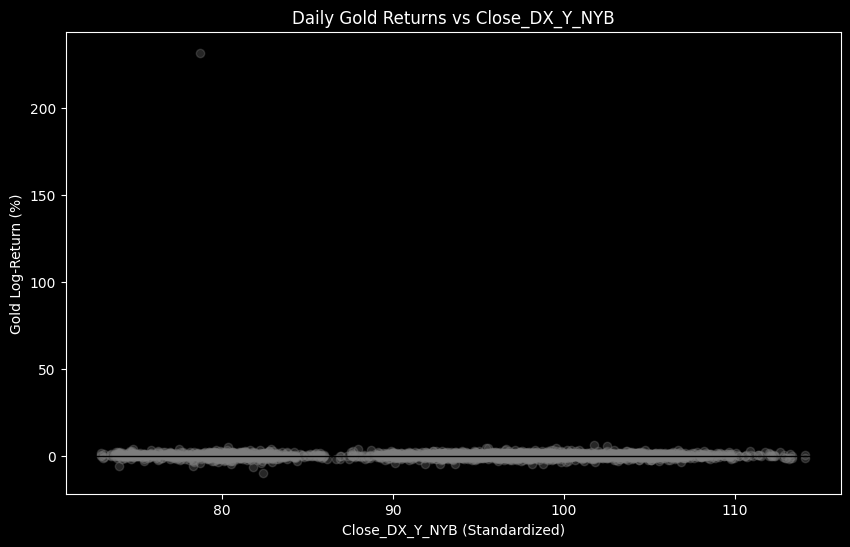

In [3]:
# final results
if not selected_features.empty:
    plt.figure(figsize=(10, 6))
    selected_features.plot(kind='barh', color='gold')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title("LASSO Feature Selection: Drivers of Gold Returns")
    plt.xlabel("Standardized Coefficient Value (Scaled x100)")
    plt.tight_layout()
    plt.show()

    handoff_list = selected_features.index.tolist()
    print("LASSO selected Variables for Member 4:")
    print(handoff_list)
else:
    # fallback: if LASSO zeros out, we pick the top 3 based on absolute correlation
    print("Warning: LASSO zeroed out all Coefficients.")
    top_correlated = correlations.abs().sort_values(ascending=False)
    handoff_list = top_correlated.index[1:4].tolist()
    print("Fallback: Recommended Variables for Member 4 based on Correlation:")
    print(handoff_list)

# defining the final research features for the OLS Model
# we use absolute values as strong negative correlation is equally important
abs_corr = df[features + ['gold_ret']].corr()['gold_ret'].abs().sort_values(ascending=False)
potential_drivers = abs_corr.drop('gold_ret')

# selecting the top variables and forcing the interaction Term into the handoff
handoff_vars = potential_drivers.head(3).index.tolist()
if 'VIX_x_PostCovid' not in handoff_vars:
    handoff_vars.append('VIX_x_PostCovid')

print(f"\nFinal Handoff for OLS: {handoff_vars}")

# visualizing why the LASSO struggled to select coefficients
# plotting Gold Returns against the top correlated variable
top_var = potential_drivers.index[0]
plt.figure(figsize=(10, 6))
plt.scatter(df[top_var], df['gold_ret'] * 100, alpha=0.3, color='gray')
plt.axhline(0, color='black', lw=1)
plt.title(f"Daily Gold Returns vs {top_var}")
plt.xlabel(f"{top_var} (Standardized)")
plt.ylabel("Gold Log-Return (%)")
plt.show()